> Main code


In [33]:
import logging
logging.getLogger().setLevel(logging.ERROR)

In [19]:
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm  

def select_reference_image_cv(dataset_root, extensions=(".png", ".jpg", ".tif")):
    """
    Traverse all subfolders under dataset_root, compute mean RGB for each image using OpenCV,
    and select the image closest to the overall mean as reference.
    
    Args:
        dataset_root (str or Path): Root folder of dataset
        extensions (tuple): Image file extensions to include
    
    Returns:
        reference_image_path (str): Path to selected reference image
        overall_mean (np.array): Overall mean RGB
    """
    dataset_root = Path(dataset_root)
    
    # Collect all image paths
    image_paths = [p for p in dataset_root.rglob("*") if p.suffix.lower() in extensions]
    if len(image_paths) == 0:
        raise ValueError("No images found in dataset.")
    
    means = []
    
    print(f"[INFO] Processing {len(image_paths)} images to compute mean RGB...")

    # iterate with tqdm
    for img_path in tqdm(image_paths, desc="Computing mean RGB"):
        img = cv2.imread(str(img_path))  # BGR
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert to RGB
        mean_channels = img.mean(axis=(0,1)) / 255.0  # normalize to [0,1]
        means.append(mean_channels)
    
    means = np.array(means)
    
    # Compute overall mean
    overall_mean = np.mean(means, axis=0)
    
    # Compute Euclidean distances to overall mean
    distances = np.sqrt(np.sum((means - overall_mean)**2, axis=1))
    
    # Select image with minimum distance
    min_idx = np.argmin(distances)
    reference_image = str(image_paths[min_idx])
    min_dist = distances[min_idx]
    
    print(f"[RESULT] Overall mean RGB (normalized [0,1]): {overall_mean}")
    print(f"[RESULT] Selected reference image: {reference_image}")
    print(f"[RESULT] Minimum distance to overall mean: {min_dist}")
    
    return reference_image, overall_mean

# ---------------- Usage Example ----------------
dataset_root = "BreaKHis Organized Binary"  
ref_image, overall_mean = select_reference_image_cv(dataset_root)

[INFO] Processing 7909 images to compute mean RGB...


Computing mean RGB: 100%|██████████| 7909/7909 [04:32<00:00, 29.02it/s]

[RESULT] Overall mean RGB (normalized [0,1]): [0.78676926 0.62625962 0.7641772 ]
[RESULT] Selected reference image: BreaKHis Organized Binary\Malignant\200X\SOB_M_DC-14-12312-200-005.png
[RESULT] Minimum distance to overall mean: 0.004001724968651439


In [34]:
from pathlib import Path
import cv2
import numpy as np
from tiatoolbox.utils.misc import imread, imwrite
from tiatoolbox.tools.stainnorm import get_normalizer
from tiatoolbox.tools.tissuemask import OtsuTissueMasker, MorphologicalMasker
from tqdm import tqdm  # <--- added tqdm

# ---------------- Single Image ----------------
def process_single_image(img_path, ref_path, mask_method="otsu"):
    img = imread(img_path)
    ref = imread(ref_path)

    # ---- tissue mask ----
    mask_method = mask_method.lower()
    if mask_method == "otsu":
        masker = OtsuTissueMasker()
        masker.fit(img[np.newaxis, ...])
        mask = masker.transform([img])[0]
    elif mask_method == "morphological":
        masker = MorphologicalMasker()
        masker.fit([img])
        mask = masker.transform([img])[0]
    else:
        raise ValueError("mask_method must be 'otsu' or 'morphological'")

    # tissue only
    tissue_only = img.copy()
    tissue_only[mask == 0] = 255

    # ---- normalization ----
    def normalize(method_name):
        norm = get_normalizer(method_name.lower())
        norm.fit(ref)
        norm_img = norm.transform(img)
        norm_img[mask == 0] = 255
        return norm_img

    return {
        "original": img,
        "mask": mask,
        "tissue_only": tissue_only,
        "macenko": normalize("macenko"),
        "vahadane": normalize("vahadane"),
        "reinhard": normalize("reinhard"),
        "ruifrok": normalize("ruifrok")
    }

# ---------------- Dataset Wrapper with tqdm ----------------
def process_dataset(
    input_root,
    ref_path,
    output_root="preprocessed_dataset",
    mask_method="otsu",
    resize_shape=(224,224)
):
    """
    Traverse dataset folder with subfolders, process all images, save them.
    Folder structure is preserved inside each normalization type.
    Shows a tqdm progress bar.
    """
    input_root = Path(input_root)
    methods = ["macenko", "vahadane", "reinhard", "ruifrok", "tissue_only"]

    # collect all image paths first
    all_image_paths = [
        img_path
        for class_folder in input_root.iterdir() if class_folder.is_dir()
        for mag_folder in class_folder.iterdir() if mag_folder.is_dir()
        for img_path in mag_folder.glob("*.*")
    ]

    print(f"[INFO] Total images to process: {len(all_image_paths)}")

    # iterate with tqdm
    for img_path in tqdm(all_image_paths, desc="Processing Images"):
        class_folder = img_path.parents[1].name
        mag_folder = img_path.parents[0].name
        try:
            results = process_single_image(str(img_path), str(ref_path), mask_method)

            for method in methods:
                out_folder = Path(output_root) / f"{method}_normalized" / class_folder / mag_folder
                out_folder.mkdir(parents=True, exist_ok=True)

                img_to_save = results[method]
                img_resized = cv2.resize(img_to_save, resize_shape, interpolation=cv2.INTER_AREA)
                if img_resized.dtype in (np.float32, np.float64):
                    img_resized = (np.clip(img_resized, 0, 255)).astype(np.uint8)

                out_file = out_folder / img_path.name
                cv2.imwrite(str(out_file), cv2.cvtColor(img_resized, cv2.COLOR_RGB2BGR))

        except Exception as e:
            print(f"[ERROR] {img_path} -> {e}")

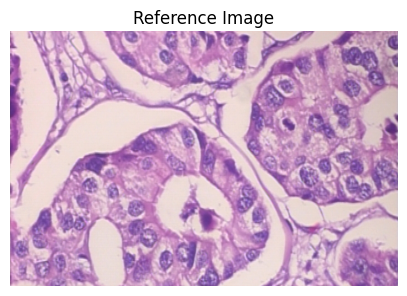

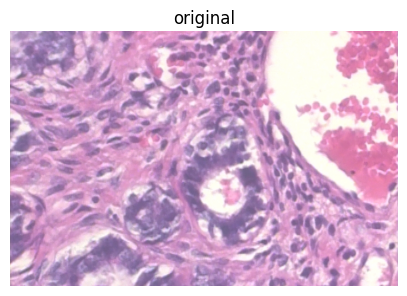

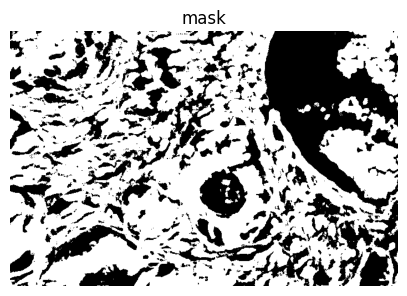

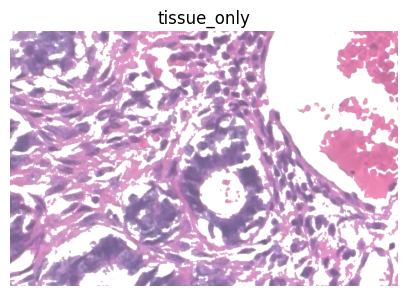

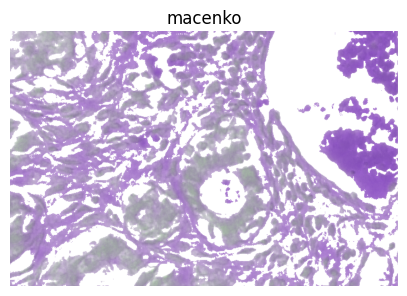

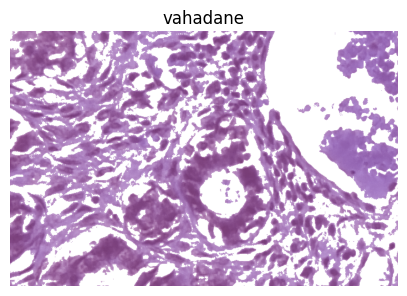

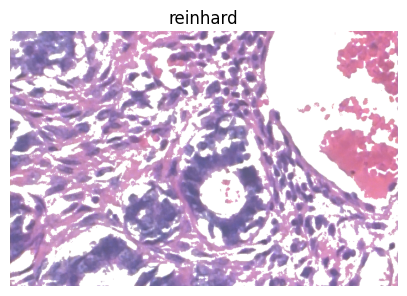

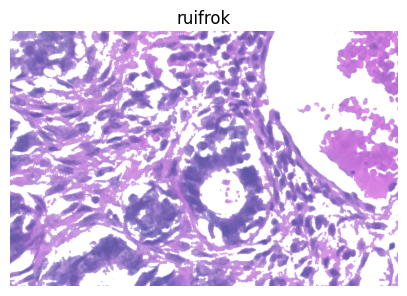

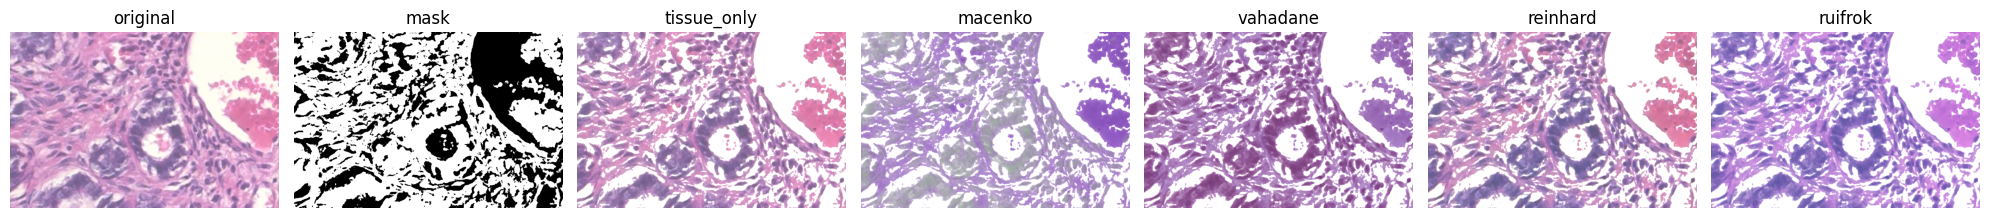

In [35]:
import matplotlib.pyplot as plt
import numpy as np

img_path = r"BreaKHis Organized Binary\Benign\200X\SOB_B_TA-14-16184-200-004.png"
reference_image_path = r"BreaKHis Organized Binary\Malignant\200X\SOB_M_DC-14-12312-200-005.png"
results = process_single_image(img_path, reference_image_path)

# Separate display
ref = imread(reference_image_path).astype(np.uint8)
plt.figure(figsize=(5,5))
plt.title("Reference Image")
plt.axis("off")
plt.imshow(ref)

for name, img in results.items():
    plt.figure(figsize=(5,5))
    if img.ndim == 2:  # mask
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)
    plt.title(name)
    plt.axis("off")
    plt.show()

# Combined display
images = ["original", "mask", "tissue_only", "macenko", "vahadane", "reinhard", "ruifrok"]
plt.figure(figsize=(20,5))
for i, name in enumerate(images, 1):
    img = results[name]
    plt.subplot(1, len(images), i)
    if img.ndim == 2:  # mask
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)
    plt.title(name)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [36]:
process_dataset(
    input_root="BreaKHis Organized Binary",
    ref_path=reference_image_path,
    output_root="preprocessed_breakhis_dataset",
    mask_method="otsu",
    resize_shape=(224,224)
)

[INFO] Total images to process: 7909


Processing Images: 100%|██████████| 7909/7909 [3:13:38<00:00,  1.47s/it]  
